# 04 — Обнаружение периодов недозаселения

## Цель ноутбука

После построения финального прогноза нужно найти будущие даты, где ожидается недозаселение. Эти даты затем используются рекомендательным модулем для выбора клиентских сегментов и маркетинговых действий.

## Логика бизнес-порога

Старый вариант `seasonal p60 load_rate` слишком мягко оценивал низкий сезон: для зимы цель получалась около 181 бронирования/день. Для рекомендательной системы это плохо, потому что она должна помогать повышать загрузку, а не только фиксировать экстремальные провалы.

Поэтому используем гибридный бизнес-порог:

- берем сезонный 75-й перцентиль `load_rate` как stretch-ориентир внутри сезона;
- берем общий 50-й перцентиль `load_rate` как минимальный бизнес-floor для низких сезонов;
- итоговый `target_rate_business = max(seasonal_p75, global_p50)`;
- переводим его в активные бронирования через `capacity_est`.

Так зима и весна не получают искусственно низкую планку, а лето остается привязанным к своей высокой сезонной норме.

## Что считается риском

Дата попадает в риск недозаселения, если `yhat < target_load_season`. Для совместимости с downstream-ноутбуками поле называется `target_load_season`, но по смыслу это бизнес-порог загрузки. Для каждой такой даты считаем прогнозную загрузку, разрыв `load_gap_season`, процент недозаселения и период риска.

## Выходы

- `underload_dates.parquet`
- `underload_periods.parquet`


## 1. Импорты и данные

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

if Path('artifacts_forecasting').exists():
    OUT_DIR = Path('artifacts_forecasting')
elif Path('forecasting/artifacts_forecasting').exists():
    OUT_DIR = Path('forecasting') / 'artifacts_forecasting'
else:
    raise FileNotFoundError('artifacts_forecasting was not found. Run from ml/ or ml/forecasting/.')

df_daily = pd.read_parquet(OUT_DIR / 'df_daily.parquet')
df_forecast = pd.read_parquet(OUT_DIR / 'forecast_best.parquet')
df_daily['ds'] = pd.to_datetime(df_daily['ds'])
df_forecast['ds'] = pd.to_datetime(df_forecast['ds'])
TODAY = df_daily['ds'].max()

print(f'History ends: {TODAY.date()}')
print(f'Forecast rows: {len(df_forecast):,}')


C:\Users\sp1ts\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


History ends: 2025-10-30
Forecast rows: 1,764


## 1.1. Связь с EDA и моделью

EDA показал две вещи: сезонность действительно сильная, но историческая зимняя загрузка слишком низкая, чтобы считать ее бизнес-целью. Поэтому риск недозаселения считаем не относительно мягкой сезонной нормы, а относительно гибридного бизнес-порога `max(seasonal p75, global p50)`.


## 2. Бизнес-порог загрузки


In [2]:
def month_to_season(month: int) -> str:
    if month in (12, 1, 2):
        return 'winter'
    if month in (3, 4, 5):
        return 'spring'
    if month in (6, 7, 8):
        return 'summer'
    return 'autumn'

if 'season' not in df_daily.columns:
    df_daily['season'] = df_daily['ds'].dt.month.map(month_to_season)
if 'year' not in df_daily.columns:
    df_daily['year'] = df_daily['ds'].dt.year

USE_CAPACITY = {'load_rate', 'capacity_est'}.issubset(df_daily.columns)
SEASONAL_TARGET_QUANTILE = 0.75
BUSINESS_FLOOR_QUANTILE = 0.50

if USE_CAPACITY:
    target_rate_global = float(df_daily['load_rate'].quantile(BUSINESS_FLOOR_QUANTILE))
    seasonal_raw_thresholds = df_daily.groupby('season')['load_rate'].quantile(SEASONAL_TARGET_QUANTILE).round(4).to_dict()
    seasonal_thresholds = {
        season: round(max(float(rate), target_rate_global), 4)
        for season, rate in seasonal_raw_thresholds.items()
    }
    print('Threshold mode: max(seasonal p75 load_rate, global p50 load_rate) * capacity_est')
    print(f'Business floor load_rate: {target_rate_global:.4f}')
    print('Raw seasonal p75 load_rate:')
    print(seasonal_raw_thresholds)
else:
    target_load_global = float(df_daily['y'].quantile(BUSINESS_FLOOR_QUANTILE))
    seasonal_raw_thresholds = df_daily.groupby('season')['y'].quantile(SEASONAL_TARGET_QUANTILE).round(1).to_dict()
    seasonal_thresholds = {
        season: round(max(float(value), target_load_global), 1)
        for season, value in seasonal_raw_thresholds.items()
    }
    print('Threshold mode: max(seasonal p75 active bookings, global p50 active bookings)')

print('Business thresholds:')
print(seasonal_thresholds)


Threshold mode: max(seasonal p75 load_rate, global p50 load_rate) * capacity_est
Business floor load_rate: 0.4481
Raw seasonal p75 load_rate:
{'autumn': 0.7006, 'spring': 0.4787, 'summer': 0.8936, 'winter': 0.2755}
Business thresholds:
{'autumn': 0.7006, 'spring': 0.4787, 'summer': 0.8936, 'winter': 0.4481}


## 3. Будущий горизонт прогноза

In [3]:
df_future = df_forecast[df_forecast['ds'] > TODAY].copy()
df_future['month'] = df_future['ds'].dt.month
df_future['year'] = df_future['ds'].dt.year
df_future['weekday'] = df_future['ds'].dt.dayofweek
df_future['is_weekend'] = (df_future['weekday'] >= 5).astype(int)
df_future['season'] = df_future['month'].map(month_to_season)

if USE_CAPACITY:
    capacity_by_year = df_daily.groupby('year')['capacity_est'].first().to_dict()
    last_capacity = float(df_daily.sort_values('ds')['capacity_est'].iloc[-1])
    if 'capacity_est' not in df_future.columns:
        df_future['capacity_est'] = df_future['year'].map(capacity_by_year).fillna(last_capacity).astype(float)
    df_future['target_rate_global'] = target_rate_global
    df_future['target_rate_season_raw'] = df_future['season'].map(seasonal_raw_thresholds)
    df_future['target_rate_season'] = df_future['season'].map(seasonal_thresholds)
    df_future['target_load_global'] = (df_future['target_rate_global'] * df_future['capacity_est']).round(1)
    df_future['target_load_season_raw'] = (df_future['target_rate_season_raw'] * df_future['capacity_est']).round(1)
    df_future['target_load_season'] = (df_future['target_rate_season'] * df_future['capacity_est']).round(1)
else:
    df_future['target_load_global'] = target_load_global
    df_future['target_load_season_raw'] = df_future['season'].map(seasonal_raw_thresholds)
    df_future['target_load_season'] = df_future['season'].map(seasonal_thresholds)

print(f'Future horizon: {len(df_future):,} days')
display(df_future[['ds', 'yhat', 'target_load_season', 'season']].head())


Future horizon: 365 days


,ds,yhat,target_load_season,season
1399,2025-10-31,293.181837,545.8,autumn
1400,2025-11-01,291.080857,545.8,autumn
1401,2025-11-02,280.187737,545.8,autumn
1402,2025-11-03,296.921270,545.8,autumn
1403,2025-11-04,338.356976,545.8,autumn


## 4. Поиск дат недозаселения

In [4]:
df_future['is_underload'] = (df_future['yhat'] < df_future['target_load_season']).astype(int)
df_future['is_underload_season'] = df_future['is_underload']
df_future['load_gap_global'] = (df_future['target_load_global'] - df_future['yhat']).clip(lower=0).round(1)
df_future['load_gap_season'] = (df_future['target_load_season'] - df_future['yhat']).clip(lower=0).round(1)
df_future['underload_pct'] = (df_future['load_gap_season'] / df_future['target_load_season'] * 100).round(1)

df_underload = df_future[df_future['is_underload'] == 1].sort_values('ds').copy()

print(f'Underload days: {len(df_underload):,} of {len(df_future):,} ({len(df_underload) / len(df_future):.1%})')
display(df_underload[['ds', 'yhat', 'target_load_season', 'load_gap_season', 'underload_pct', 'season']].head())


Underload days: 160 of 365 (43.8%)


,ds,yhat,target_load_season,load_gap_season,underload_pct,season
1399,2025-10-31,293.181837,545.8,252.6,46.3,autumn
1400,2025-11-01,291.080857,545.8,254.7,46.7,autumn
1401,2025-11-02,280.187737,545.8,265.6,48.7,autumn
1402,2025-11-03,296.921270,545.8,248.9,45.6,autumn
1403,2025-11-04,338.356976,545.8,207.4,38.0,autumn


## 5. Группировка дат в периоды

In [5]:
df_underload = df_underload.sort_values('ds').reset_index(drop=True)
df_underload['day_diff'] = df_underload['ds'].diff().dt.days.fillna(1)
df_underload['period_id'] = (df_underload['day_diff'] > 2).cumsum()

df_periods = (
    df_underload.groupby('period_id')
    .agg(
        period_start=('ds', 'min'),
        period_end=('ds', 'max'),
        n_days=('ds', 'count'),
        avg_yhat=('yhat', 'mean'),
        avg_gap=('load_gap_season', 'mean'),
        max_gap=('load_gap_season', 'max'),
        avg_underload_pct=('underload_pct', 'mean'),
        season=('season', lambda values: values.mode().iloc[0]),
    )
    .reset_index(drop=True)
)
for col in ['avg_yhat', 'avg_gap', 'max_gap', 'avg_underload_pct']:
    df_periods[col] = df_periods[col].round(1)

display(df_periods)


,period_start,period_end,n_days,avg_yhat,avg_gap,max_gap,avg_underload_pct,season
0,2025-10-31,2025-12-30,61,258.1,190.9,355.3,41.7,autumn
1,2026-01-08,2026-02-22,46,262.5,86.6,151.8,24.8,winter
2,2026-02-25,2026-03-22,25,315.9,53.2,137.5,14.4,spring
3,2026-03-29,2026-04-03,5,359.7,13.2,21.9,3.6,spring
4,2026-05-09,2026-05-11,3,364.0,8.9,25.5,2.4,spring
5,2026-06-01,2026-06-04,4,649.6,46.5,74.8,6.6,summer
6,2026-10-15,2026-10-30,16,480.1,65.7,140.4,12.0,autumn


## 6. Визуализация

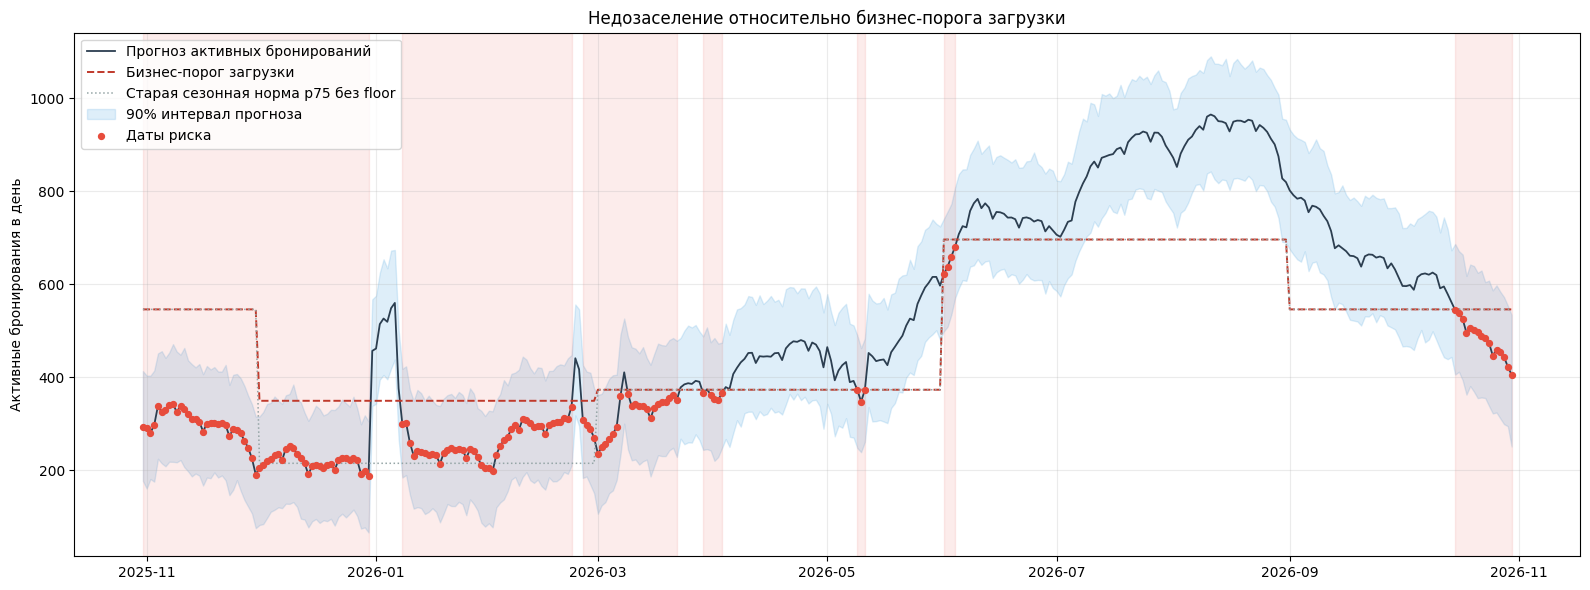

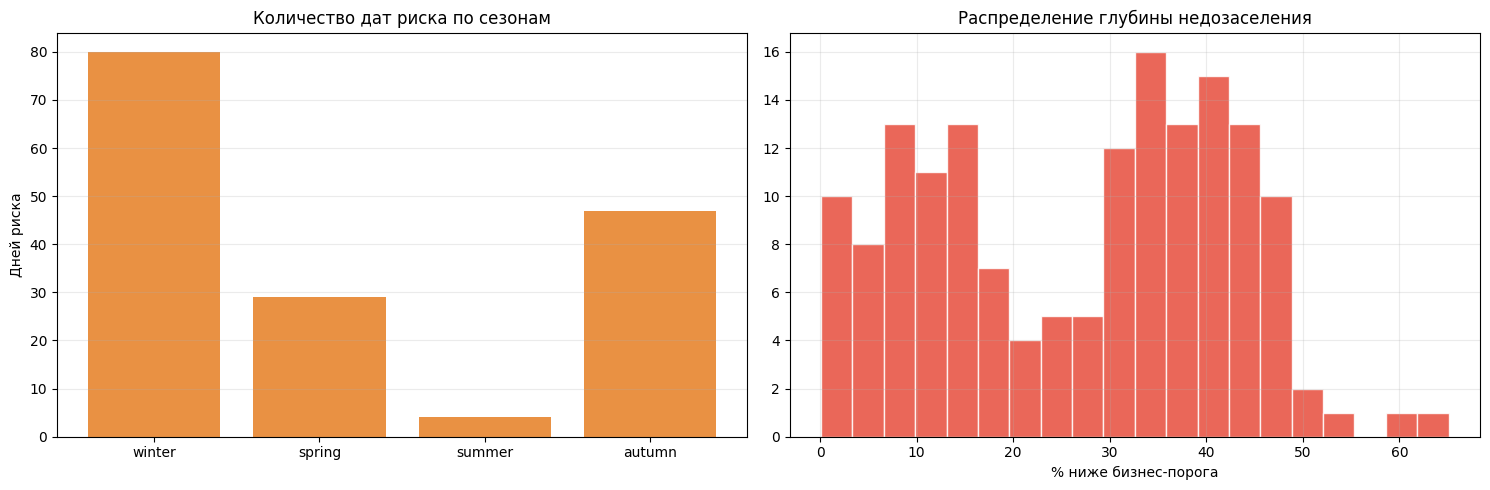

In [6]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(df_future['ds'], df_future['yhat'], label='Прогноз активных бронирований', color='#2c3e50', linewidth=1.3)
ax.plot(df_future['ds'], df_future['target_load_season'], label='Бизнес-порог загрузки', color='#c0392b', linestyle='--', linewidth=1.4)
if 'target_load_season_raw' in df_future.columns:
    ax.plot(df_future['ds'], df_future['target_load_season_raw'], label='Старая сезонная норма p75 без floor', color='#95a5a6', linestyle=':', linewidth=1.1)
ax.fill_between(df_future['ds'], df_future['yhat_lower'], df_future['yhat_upper'], color='#3498db', alpha=0.16, label='90% интервал прогноза')
if not df_underload.empty:
    ax.scatter(df_underload['ds'], df_underload['yhat'], color='#e74c3c', s=18, label='Даты риска', zorder=3)
for _, row in df_periods.iterrows():
    ax.axvspan(row['period_start'], row['period_end'], color='#e74c3c', alpha=0.10)
ax.set_title('Недозаселение относительно бизнес-порога загрузки')
ax.set_ylabel('Активные бронирования в день')
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'underload_detection.png', dpi=160, bbox_inches='tight')
plt.show()

if not df_underload.empty:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    season_counts = df_underload.groupby('season').size().reindex(['winter', 'spring', 'summer', 'autumn']).fillna(0)
    axes[0].bar(season_counts.index, season_counts.values, color='#e67e22', alpha=0.85)
    axes[0].set_title('Количество дат риска по сезонам')
    axes[0].set_ylabel('Дней риска')
    axes[0].grid(True, alpha=0.25, axis='y')

    axes[1].hist(df_underload['underload_pct'], bins=20, color='#e74c3c', alpha=0.85, edgecolor='white')
    axes[1].set_title('Распределение глубины недозаселения')
    axes[1].set_xlabel('% ниже бизнес-порога')
    axes[1].grid(True, alpha=0.25)

    plt.tight_layout()
    plt.savefig(OUT_DIR / 'underload_risk_profile.png', dpi=160, bbox_inches='tight')
    plt.show()


## 7. Сохранение артефактов недозаселения

In [7]:
underload_cols = [
    'ds', 'yhat', 'yhat_lower', 'yhat_upper', 'capacity_est',
    'target_rate_global', 'target_rate_season_raw', 'target_rate_season',
    'target_load_global', 'target_load_season_raw', 'target_load_season',
    'load_gap_global', 'load_gap_season', 'underload_pct',
    'season', 'month', 'year', 'weekday', 'is_weekend', 'period_id',
]
underload_output = df_underload[[c for c in underload_cols if c in df_underload.columns]].copy()
underload_output.to_parquet(OUT_DIR / 'underload_dates.parquet', index=False)
df_periods.to_parquet(OUT_DIR / 'underload_periods.parquet', index=False)

print(f'Saved: {OUT_DIR / "underload_dates.parquet"} ({len(underload_output):,} rows)')
print(f'Saved: {OUT_DIR / "underload_periods.parquet"} ({len(df_periods):,} rows)')


Saved: artifacts_forecasting\underload_dates.parquet (160 rows)
Saved: artifacts_forecasting\underload_periods.parquet (7 rows)


## 8. Итог

In [8]:
print('=' * 55)
print('UNDERLOAD SUMMARY')
print('=' * 55)
print(f'Forecast horizon: {len(df_future):,} days')
print(f'Underload days:   {len(df_underload):,} ({len(df_underload) / len(df_future):.1%})')
print(f'Underload periods:{len(df_periods):,}')
if len(df_underload) > 0:
    print(f'Average forecast in underload dates: {df_underload["yhat"].mean():.1f}')
    print(f'Average seasonal gap: {df_underload["load_gap_season"].mean():.1f}')
    print('')
    print('Underload days by season:')
    print(df_underload.groupby('season')['ds'].count().to_string())


UNDERLOAD SUMMARY
Forecast horizon: 365 days
Underload days:   160 (43.8%)
Underload periods:7
Average forecast in underload dates: 305.6
Average seasonal gap: 114.3

Underload days by season:
season
autumn    47
spring    29
summer     4
winter    80
